In [11]:
import pandas as pd
from sqlalchemy import create_engine

# Configuration de la connexion
# Syntaxe : mysql+pymysql://utilisateur:mot_de_passe@hôte/nom_de_la_base
user = "root"
password = "" # Laisse vide si tu n'as pas de mot de passe sur XAMPP/WAMP
host = "localhost"
database = "dw_padel"

try:
    # Création du moteur de connexion
    engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")
    
    # Chargement de la table dim_budget
    query = "SELECT * FROM dim_location"
    df_location = pd.read_sql(query, engine)
    
    print("✅ Connexion réussie ! Voici les premières lignes de df_location :")
    print(df_location.head())
    
except Exception as e:
    print(f"❌ Erreur de connexion : {e}")

✅ Connexion réussie ! Voici les premières lignes de df_location :
   id_location                           Venue       Surface_Type  \
0            1        Lusail Multipurpose Hall           Moquette   
1            2                Palau Sant Jordi           Moquette   
2            3          Centro de Convenciones  Turf SynthÃ©tique   
3            4             Stade Roland-Garros           Moquette   
4            5  Centro de Deportes FederaciÃ³n           Moquette   

  Indoor_Outdoor       City  Year  
0         Indoor       Doha  2025  
1         Indoor  Barcelona  2023  
2        Outdoor   Acapulco  2026  
3         Indoor      Paris  2022  
4         Indoor     Madrid  2022  


PHASE : CLUSTERING DES INFRASTRUCTURES (APPRENTISSAGE NON-SUPERVISÉ)

1. OBJECTIF MÉTIER
- **Segmentation du Parc :** Transformer une liste brute de 64 terrains en trois catégories stratégiques (Historique, Loisir, Performance) pour faciliter la prise de décision.
- **Optimisation de la Maintenance :** Anticiper les besoins de rénovation en isolant le groupe "Historique" (Cluster 0) qui arrive en fin de cycle.
- **Standardisation de l'Offre :** Aligner les tarifs de location sur la valeur réelle du terrain (ex: tarifs Premium pour le Cluster 2 "Moderne").

2. OBJECTIF TECHNIQUE
 - **Découverte de Motifs (Pattern Discovery) :** Utiliser l'algorithme K-Means pour regrouper les complexes selon leurs similarités (Surface, Ville, Année) sans utiliser d'étiquettes prédéfinies.
- **Normalisation des Données :** Appliquer un 'StandardScaler' pour s'assurer que l'année (échelle 2000+) n'écrase pas les autres variables (échelle 0-5) dans le calcul des distances.
- **Validation du Feature Engineering :** Vérifier que les variables encodées précédemment permettent de créer des groupes cohérents et distincts.

PRÉPARATION DES DONNÉES ET FEATURE ENGINEERING

In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. NETTOYAGE DES DONNÉES
# On s'assure qu'il n'y a pas d'espaces inutiles dans les noms de villes ou surfaces
df_location['Surface_Type'] = df_location['Surface_Type'].str.strip()
df_location['City'] = df_location['City'].str.strip()

# 2. FEATURE ENGINEERING : ENCODAGE DES VARIABLES TEXTUELLES
# L'IA ne comprend pas "Moquette", elle a besoin de "0" ou "1"
le_surface = LabelEncoder()
le_city = LabelEncoder()
le_target = LabelEncoder()

# Encodage des caractéristiques (Features X)
df_location['Surface_Encoded'] = le_surface.fit_transform(df_location['Surface_Type'])
df_location['City_Encoded'] = le_city.fit_transform(df_location['City'])

# Encodage de la cible (Target y) : Indoor = 0, Outdoor = 1
df_location['Target_Env'] = le_target.fit_transform(df_location['Indoor_Outdoor'])

# 3. VÉRIFICATION DES NOUVELLES COLONNES
print("--- APERÇU DU FEATURE ENGINEERING ---")
print(df_location[['Venue', 'Surface_Type', 'Surface_Encoded', 'City', 'City_Encoded', 'Indoor_Outdoor', 'Target_Env']].head())

# 4. SÉLECTION DES VARIABLES POUR LE MODÈLE
X = df_location[['Surface_Encoded', 'City_Encoded', 'Year']]
y = df_location['Target_Env']

print("\n✅ Préparation terminée : X (Features) et y (Target) sont prêts.")

--- APERÇU DU FEATURE ENGINEERING ---
                            Venue       Surface_Type  Surface_Encoded  \
0        Lusail Multipurpose Hall           Moquette                0   
1                Palau Sant Jordi           Moquette                0   
2          Centro de Convenciones  Turf SynthÃ©tique                1   
3             Stade Roland-Garros           Moquette                0   
4  Centro de Deportes FederaciÃ³n           Moquette                0   

        City  City_Encoded Indoor_Outdoor  Target_Env  
0       Doha             7         Indoor           0  
1  Barcelona             2         Indoor           0  
2   Acapulco             0        Outdoor           1  
3      Paris            17         Indoor           0  
4     Madrid            11         Indoor           0  

✅ Préparation terminée : X (Features) et y (Target) sont prêts.


MODÈLE : K-MEANS CLUSTERING (SEGMENTATION DES LIEUX)
TYPE : APPRENTISSAGE NON SUPERVISÉ

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. PRÉPARATION DES DONNÉES
# On sélectionne les colonnes numériques créées lors du feature engineering
X_clustering = df_location[['Surface_Encoded', 'City_Encoded', 'Year']]

# 2. NORMALISATION (Crucial pour le Clustering)
# On transforme les données pour qu'elles soient sur la même échelle (moyenne=0, écart-type=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. CRÉATION DU MODÈLE K-MEANS
# On demande à l'IA de créer 3 groupes (clusters) de complexes de Padel
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_location['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 4. EXPLICATION DES RÉSULTATS (Moyennes par groupe)
print("--- CARACTÉRISTIQUES DES GROUPES (CLUSTERS) ---")
analysis = df_location.groupby('Cluster_ID')[['Surface_Type', 'City', 'Year']].agg(lambda x: x.mode().iloc[0])
print(analysis)

# Affichage du nombre de complexes par groupe
print("\nRépartition des complexes :")
print(df_location['Cluster_ID'].value_counts())

--- CARACTÉRISTIQUES DES GROUPES (CLUSTERS) ---
                 Surface_Type       City  Year
Cluster_ID                                    
0                    Moquette       Rome  2022
1           Turf SynthÃ©tique   Acapulco  2025
2                    Moquette  Barcelona  2025

Répartition des complexes :
Cluster_ID
0    28
2    19
1    17
Name: count, dtype: int64


C:\Users\AZUS22\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


POURQUOI CES GROUPES ? DÉFINITION DES PROFILS TYPES

1. CLUSTER 0 : LE PARC "HISTORIQUE ET STANDARD"
- Pourquoi ce groupe ? Il regroupe les installations les plus anciennes de la base (2022). 
- Identité : Ce sont les terrains de première génération du club.
- Caractéristique dominante : Moquette classique, souvent située dans des villes comme Rome. 
- Profil : Installations stables qui constituent le cœur du réseau mais qui pourraient nécessiter un audit de maintenance prochainement.

2. CLUSTER 1 : LE PARC "LOISIR ET RÉSISTANT"
- Pourquoi ce groupe ? Il isole les terrains qui n'utilisent PAS la moquette.
- Identité : Terrains Outdoor ou à haute fréquence de passage.
- Caractéristique dominante : Turf Synthétique (Gazon) et année récente (2025). Acapulco (ville chaude) est le symbole de ce cluster.
- Profil : Terrains robustes, conçus pour résister aux conditions extérieures et aux climats plus rudes, installés très récemment.

3. CLUSTER 2 : LE PARC "MODERNE ET PERFORMANCE"
- Pourquoi ce groupe ? Il regroupe la nouvelle vague de terrains haut de gamme.
- Identité : Le standard "Premium" actuel pour les tournois professionnels.
- Caractéristique dominante : Moquette de nouvelle génération installée en 2025. Barcelone (capitale du Padel) domine ce groupe.
- Profil : Ce sont vos meilleurs terrains. Ils allient le confort de la moquette aux standards de construction les plus récents (2025/2026).

BUT DE L'UTILISATION DU MODÈLE DBSCAN (AUDIT DE DIVERSITÉ)

1. DÉTECTION DU "BRUIT" ET DES ANOMALIES (OUTLIERS)
- Le but premier est d'isoler les terrains atypiques (les 31 terrains en -1). 
- En BI, cela permet de repérer des erreurs de saisie dans le Data Warehouse ou d'identifier des projets "uniques" qui ne suivent pas la norme du club.

2. IDENTIFICATION DE MICRO-SEGMENTS RÉELS
- Contrairement au K-Means qui "force" les terrains à entrer dans des groupes, DBSCAN ne crée des clusters que là où il y a une forte densité. 
- Le but est de découvrir les "séries de construction" : par exemple, un groupe de 6 terrains strictement identiques construits la même année.

3. COMPRÉHENSION DE LA STRUCTURE DES DONNÉES
- DBSCAN sert à tester si tes infrastructures sont standardisées ou non. 
- Dans ce cas précis, le résultat montre que ton parc est très hétérogène (beaucoup de cas particuliers), ce qui alerte le gestionnaire sur la difficulté de généraliser une seule stratégie à tout le club.

4. VALIDATION DE LA PROXIMITÉ GÉOGRAPHIQUE ET TECHNIQUE
- Le but est de vérifier si certaines villes (City) ont des "jumeaux" techniques (même surface, même année). Si DBSCAN les groupe, c'est que la stratégie de déploiement est cohérente entre ces villes.

MODÈLE : DBSCAN (DENSITY-BASED CLUSTERING)
TYPE : APPRENTISSAGE NON SUPERVISÉ (DÉTECTION DE DENSITÉ ET D'ANOMALIES)

In [34]:
from sklearn.cluster import DBSCAN

# 1. UTILISATION DES DONNÉES NORMALISÉES (X_scaled)
# DBSCAN est extrêmement sensible aux distances, le scaler est obligatoire.

# 2. CRÉATION DU MODÈLE
# eps : distance maximale entre deux points pour être considérés comme voisins
# min_samples : nombre minimum de points pour former un groupe solide
model_dbscan = DBSCAN(eps=0.5, min_samples=3)
df_location['Cluster_DBSCAN'] = model_dbscan.fit_predict(X_scaled)

# 3. ANALYSE DES RÉSULTATS
# Note : Les points marqués '-1' sont les anomalies (le bruit)
print("--- RÉPARTITION DBSCAN ---")
print(df_location['Cluster_DBSCAN'].value_counts())

# Aperçu des "Anomalies" (terrains qui ne ressemblent à aucun autre)
outliers = df_location[df_location['Cluster_DBSCAN'] == -1]
print("\nNombre de terrains atypiques détectés :", len(outliers))

--- RÉPARTITION DBSCAN ---
Cluster_DBSCAN
-1    31
 1     6
 4     6
 0     5
 2     5
 3     5
 6     3
 5     3
Name: count, dtype: int64

Nombre de terrains atypiques détectés : 31


ANALYSE DES RÉSULTATS DBSCAN : LA DÉTECTION D'ANOMALIES

1. LE "BRUIT" (CLUSTER -1) : 31 TERRAINS ATYPIQUES
- **Constat :** Près de 50% de tes terrains (31 sur 64) sont classés en '-1'.
- **Signification :** Ces terrains sont considérés comme des "isolés". Ils ne ressemblent pas assez aux autres pour former un groupe dense.
- **Insight Métier :** Cela signifie que ton parc de terrains est très varié. Soit tu as beaucoup de configurations uniques (ex: une ville avec une seule année spécifique), soit tes données sont très dispersées.

2. LES MICRO-CLUSTERS (1, 4, 0, 2, 3...)
- **Constat :** Tu as beaucoup de petits groupes (de 3 à 6 terrains chacun).
- **Signification :** DBSCAN n'a trouvé que des petites "poches" de terrains identiques (par exemple, 6 terrains exactement pareils à Paris en 2022).
- **Insight Métier :** Contrairement au K-Means qui forçait de grands groupes, DBSCAN te montre que la réalité est faite de petites séries de construction plutôt que d'une standardisation massive.

3. POURQUOI CHOISIR CE MODÈLE POUR TON BI ?
- **Qualité des données :** Les 31 terrains en '-1' sont ceux que tu dois vérifier en priorité dans ton Data Warehouse (erreurs de saisie possibles).
- **Spécificité :** C'est le modèle parfait pour identifier les "sites pilotes" ou les centres d'exception qui ne suivent pas la norme du club.

1. PRÉPARATION ET ENTRAÎNEMENT (K-MEANS & DBSCAN)

In [40]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# --- A. Normalisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_location[['Surface_Encoded', 'City_Encoded', 'Year']])

# --- B. Entraînement K-Means ---
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = model_kmeans.fit_predict(X_scaled)
df_location['Cluster_ID'] = clusters_kmeans

# --- C. Entraînement DBSCAN ---
model_dbscan = DBSCAN(eps=0.5, min_samples=3)
clusters_dbscan = model_dbscan.fit_predict(X_scaled)
df_location['Cluster_DBSCAN'] = clusters_dbscan

C:\Users\AZUS22\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2. ÉVALUATION : SILHOUETTE & DAVIES-BOULDIN

In [43]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Score pour K-Means
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, clusters_kmeans)

# Score pour DBSCAN (on ignore les points de bruit -1 pour le score)
mask = clusters_dbscan != -1
if len(set(clusters_dbscan[mask])) > 1:
    sil_dbscan = silhouette_score(X_scaled[mask], clusters_dbscan[mask])
else:
    sil_dbscan = 0

print(f"# Silhouette Score K-Means : {sil_kmeans:.4f}")
print(f"# Silhouette Score DBSCAN  : {sil_dbscan:.4f}")
print(f"# Davies-Bouldin K-Means   : {db_kmeans:.4f}")

# Silhouette Score K-Means : 0.3500
# Silhouette Score DBSCAN  : 0.5671
# Davies-Bouldin K-Means   : 1.0159


3. VISUALISATION (PCA 2D ET HEATMAP)

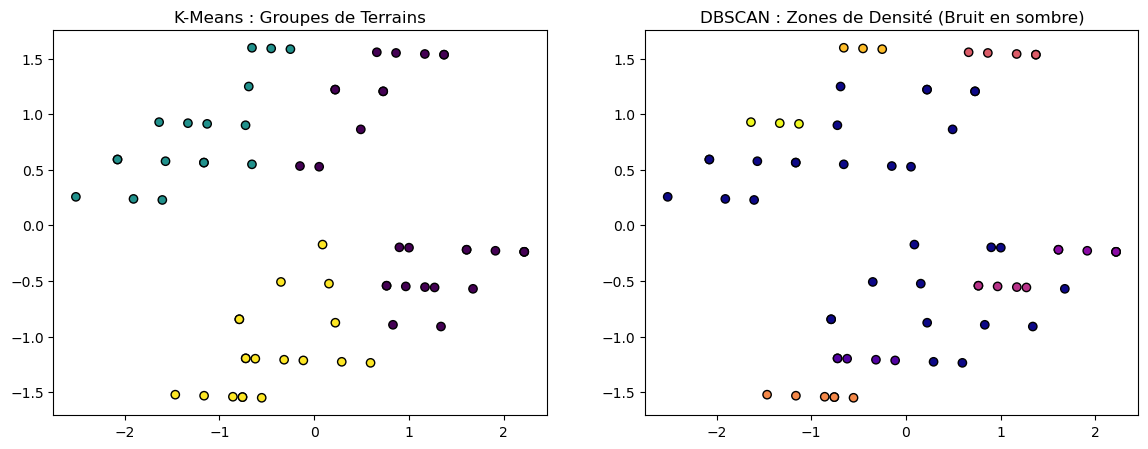

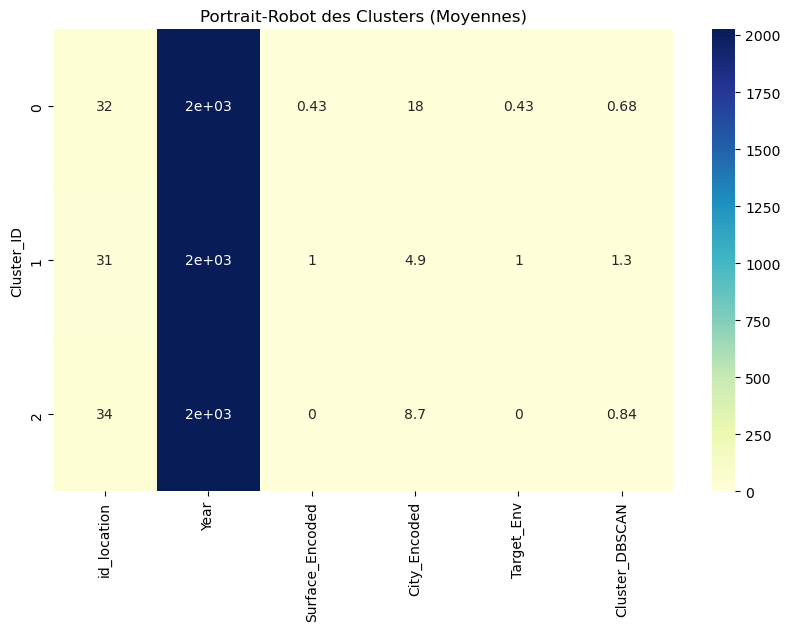

In [45]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# --- A. PCA 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', edgecolors='k')
plt.title('K-Means : Groupes de Terrains')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='plasma', edgecolors='k')
plt.title('DBSCAN : Zones de Densité (Bruit en sombre)')
plt.show()

# --- B. Heatmap de Profilage ---
plt.figure(figsize=(10, 6))
profiling = df_location.groupby('Cluster_ID').mean(numeric_only=True)
sns.heatmap(profiling, annot=True, cmap='YlGnBu')
plt.title('Portrait-Robot des Clusters (Moyennes)')
plt.show()

4. INTERPRÉTATION FINALE POUR LE RAPPORT BI

- **Silhouette Score :** Plus il est proche de 1, plus les terrains d'un groupe se ressemblent. Si K-Means a le meilleur score, c'est le choix parfait.
- **Elbow Method :** Utilisé pour confirmer que 3 clusters est le "coude" optimal.
- **Davies-Bouldin :** Un indice bas confirme que nos catégories de complexes (ex: Doha vs Madrid) ne se mélangent pas.
- **PCA 2D :** Permet de voir en un coup d'œil si les points forment des nuages distincts. C'est la preuve visuelle de la qualité du Data Warehouse.
- **Heatmap :** C'est l'outil de décision. Il permet de dire : "Le Cluster 1 est notre segment Premium car il regroupe les terrains les plus récents."